In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from dataset import load_imagenette, to_one_hot
from layers import Flatten, Dense, Conv2D, MaxPool2D
from model import Model
from functions import accuracy

Loading train images (10 classes)...


Loading val images...
X_train: (9469, 160, 160, 3), y_train: (9469,), y_train_oh: (9469, 10)
X_test:  (3925, 160, 160, 3), y_test:  (3925,), y_test_oh:  (3925, 10)


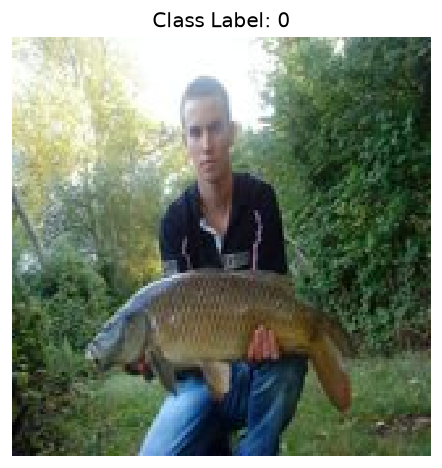

In [2]:
# Load dataset
X_train, y_train, X_test, y_test = load_imagenette(img_size=160)

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, y_train_oh: {y_train_oh.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}, y_test_oh:  {y_test_oh.shape}")

# Display one sample 
plt.figure(figsize=(4, 4), dpi=120)
plt.imshow(X_train[6], interpolation="nearest")
plt.title(f"Class Label: {y_train[6]}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# some sample for train cnn
num_train = 1000
X_tr_sub = X_train[:num_train]
y_tr_sub = y_train[:num_train]
y_tr_oh_sub = y_train_oh[:num_train]

# Instantiate individual layer 
conv1 = Conv2D(filters=8, kernel_size=5, stride=2, padding="valid", activation="relu")   
pool1 = MaxPool2D(pool_size=2)                                                            
conv2 = Conv2D(filters=16, kernel_size=3, stride=1, padding="same", activation="relu")   
pool2 = MaxPool2D(pool_size=2)                                                            
flatten = Flatten()
dense1 = Dense(units=64, activation="relu")
dense2 = Dense(units=10, activation="softmax")

# Build the model using the layers defined above.
model = Model(layers=[conv1, pool1, conv2, pool2, flatten, dense1, dense2])
model.compile(loss="categorical_crossentropy")
model.summary(input_shape=(160, 160, 3))

epochs = 10
batch_size = 32
lr = 0.05
history = {"loss": [], "accuracy": []}

print(f"\nTraining CNN on {num_train} ImageNette samples...")

for epoch in range(1, epochs + 1):
    indices = np.random.permutation(num_train)
    X_shuffled = X_tr_sub[indices]
    y_oh_shuffled = y_tr_oh_sub[indices]

    epoch_loss = 0.0
    num_batches = int(np.ceil(num_train / batch_size))

    batch_iter = tqdm(range(num_batches), desc=f"Epoch {epoch:02d}/{epochs:02d}")
    for b in batch_iter:
        start = b * batch_size
        end = min(start + batch_size, num_train)

        X_batch = X_shuffled[start:end]
        y_oh_batch = y_oh_shuffled[start:end]

        # Forward Propagation
        y_pred, caches = model.forward(X_batch)
        loss = model.loss_fn(y_pred, y_oh_batch)
        epoch_loss += loss * (end - start)

        # Back Propagation
        dA = model.loss_grad_fn(y_pred, y_oh_batch)
        model.backward(dA, caches, lr)

        batch_iter.set_postfix({"loss": f"{loss:.4f}"})

    avg_loss = epoch_loss / num_train

    # Check accuracy over training subset
    y_pred_full = model.predict(X_tr_sub)
    acc = accuracy(y_pred_full, y_tr_sub)

    history["loss"].append(avg_loss)
    history["accuracy"].append(acc)

    print(f"Epoch {epoch:02d} Summary - Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%\n")


Layer                 Output Shape        Params      
Conv2D_0              (None, *, *, 8)     608         
MaxPool2D_1           (None, *)           0           
Conv2D_2              (None, *, *, 16)    1168        
MaxPool2D_3           (None, *)           0           
Flatten_4             (None, *)           0           
Dense_5               (None, 64)          369728      
Dense_6               (None, 10)          650         
Total params: 372154

Training CNN on 1000 ImageNette samples...


Epoch 01/10: 100%|██████████| 32/32 [00:17<00:00,  1.82it/s, loss=0.3789]


Epoch 01 Summary - Loss: 0.3329 | Accuracy: 96.30%



Epoch 02/10: 100%|██████████| 32/32 [00:12<00:00,  2.47it/s, loss=0.3492]


Epoch 02 Summary - Loss: 0.1769 | Accuracy: 96.30%



...

Epoch 08 Summary - Loss: 0.1628 | Accuracy: 96.30%



Epoch 09/10: 100%|██████████| 32/32 [00:15<00:00,  2.08it/s, loss=0.0637]


Epoch 09 Summary - Loss: 0.1609 | Accuracy: 96.30%



Epoch 10/10: 100%|██████████| 32/32 [00:16<00:00,  1.98it/s, loss=0.0179]


Epoch 10 Summary - Loss: 0.1560 | Accuracy: 96.30%



In [27]:
# Evaluate model using test set
y_test_pred = model.predict(X_test[:400])
test_acc = accuracy(y_test_pred, y_test[:400])
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 96.75%


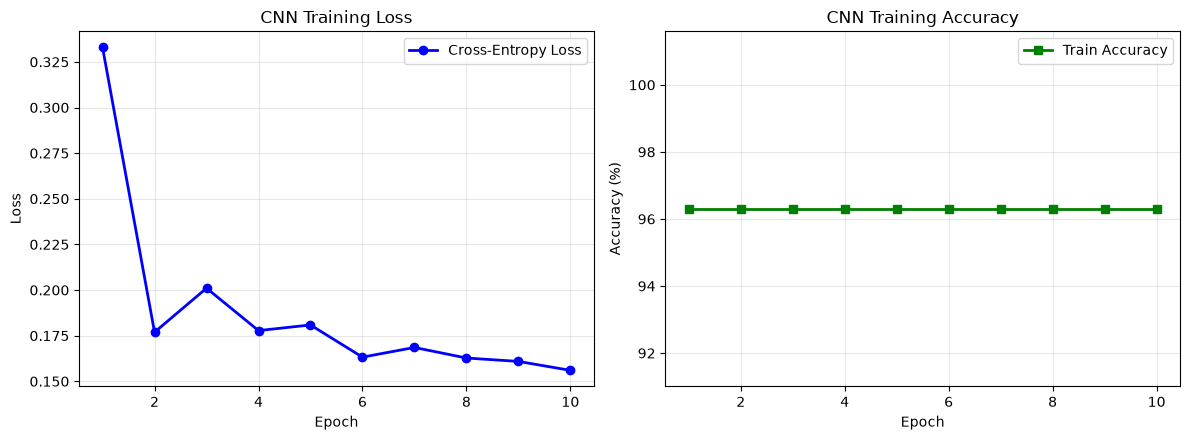

In [28]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history["loss"], "b-o", linewidth=2, label="Cross-Entropy Loss")
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history["accuracy"], "g-s", linewidth=2, label="Train Accuracy")
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


CNN conv1 Activation L2 Distance under 10px shift: 29.7418


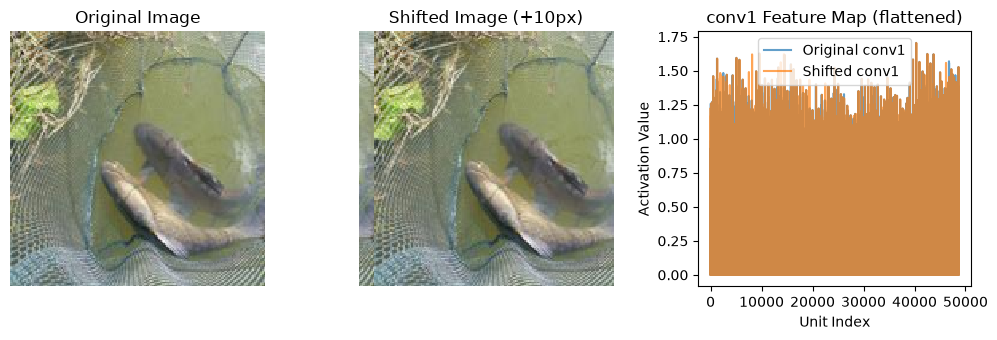

In [29]:
# Test conv1 activation stability under a small pixel shift.
shift = 10
sample_img = X_train[0:1]  # shape (1, 160, 160, 3)
sample_shifted = np.roll(sample_img, shift=shift, axis=2)  


A1_orig, _ = conv1.forward(sample_img)
A1_shifted, _ = conv1.forward(sample_shifted)

act_dist = np.linalg.norm(A1_orig - A1_shifted)
print(f"CNN conv1 Activation L2 Distance under {shift}px shift: {act_dist:.4f}")

plt.figure(figsize=(10, 3.5))

plt.subplot(1, 3, 1)
plt.imshow(sample_img[0], interpolation="nearest")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_shifted[0], interpolation="nearest")
plt.title(f"Shifted Image (+{shift}px)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(A1_orig.flatten(), label="Original conv1", alpha=0.7)
plt.plot(A1_shifted.flatten(), label="Shifted conv1", alpha=0.7)
plt.title("conv1 Feature Map (flattened)")
plt.xlabel("Unit Index")
plt.ylabel("Activation Value")
plt.legend()

plt.tight_layout()
plt.show()


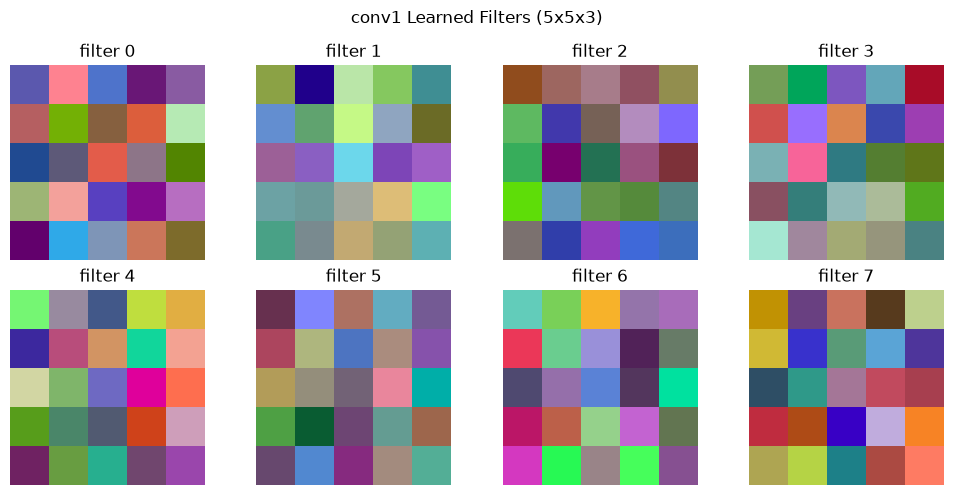

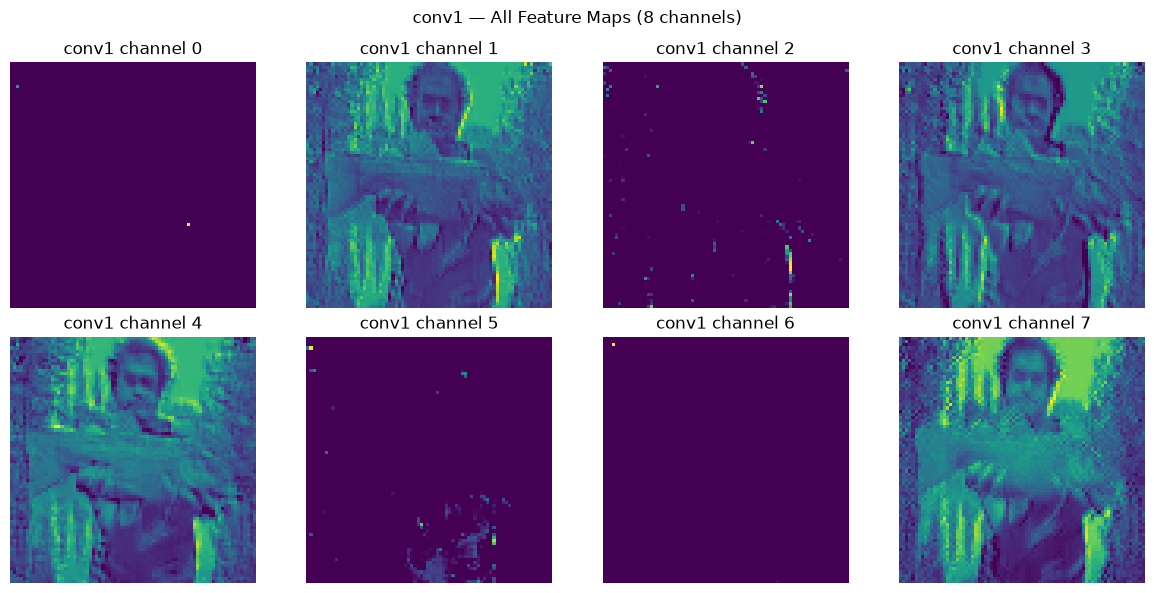

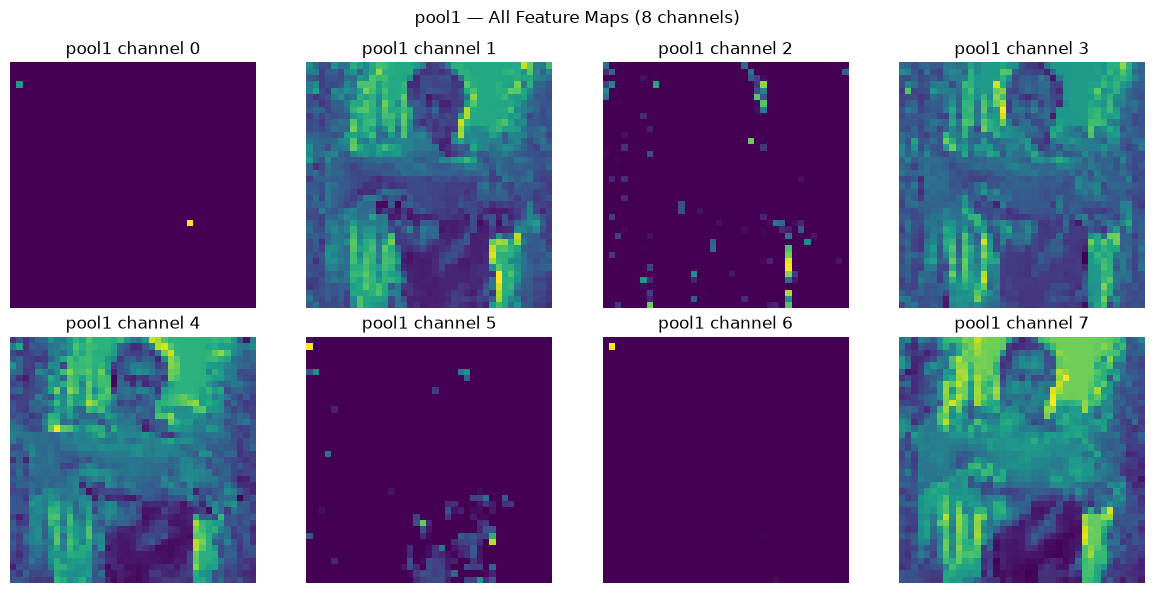

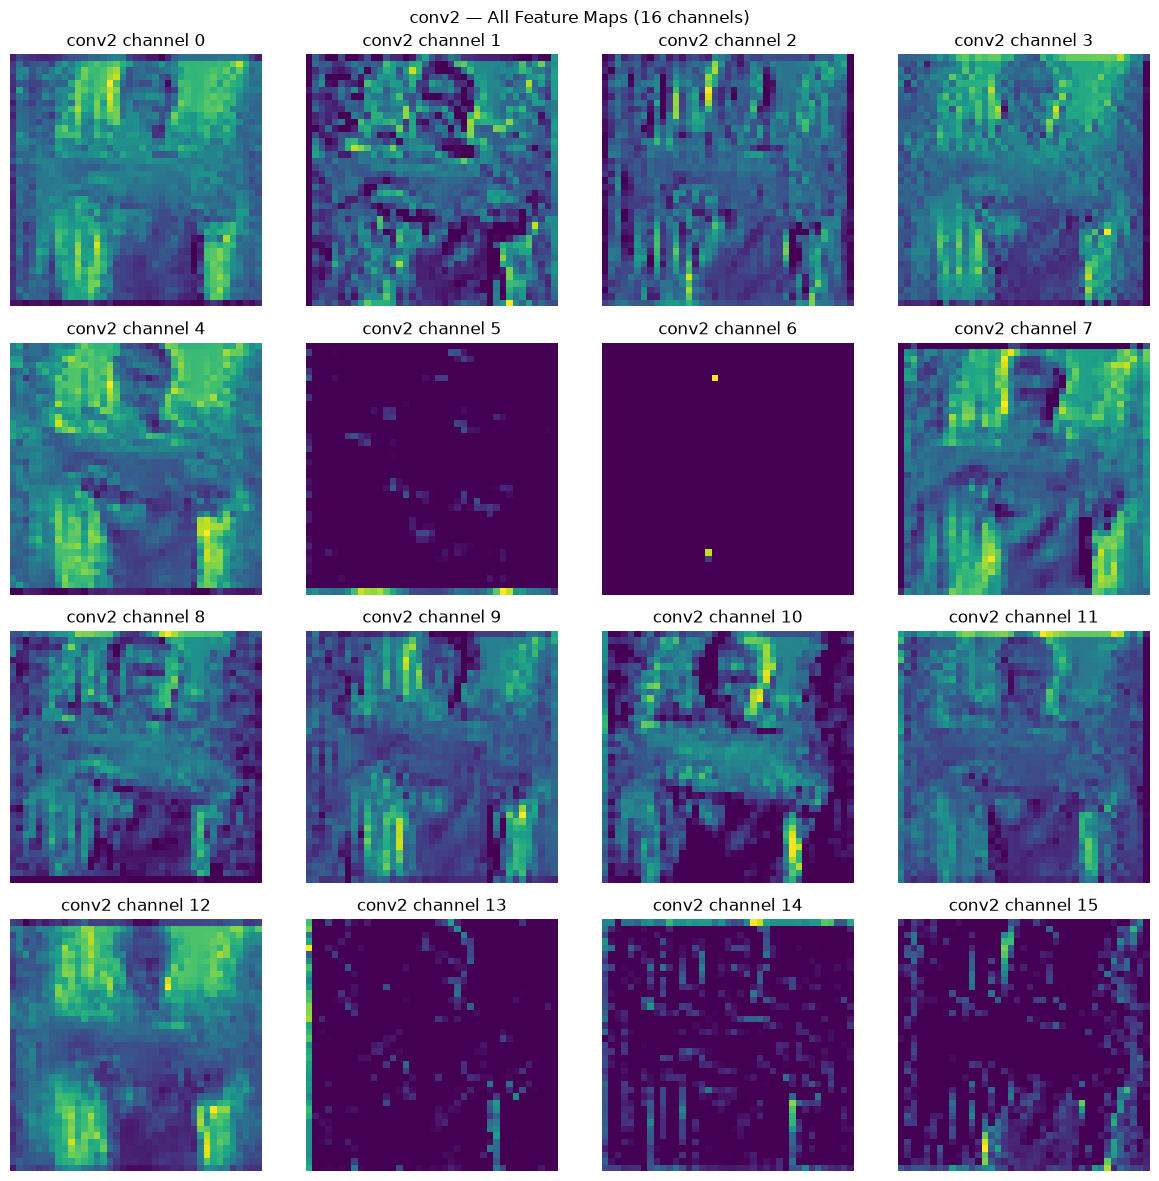

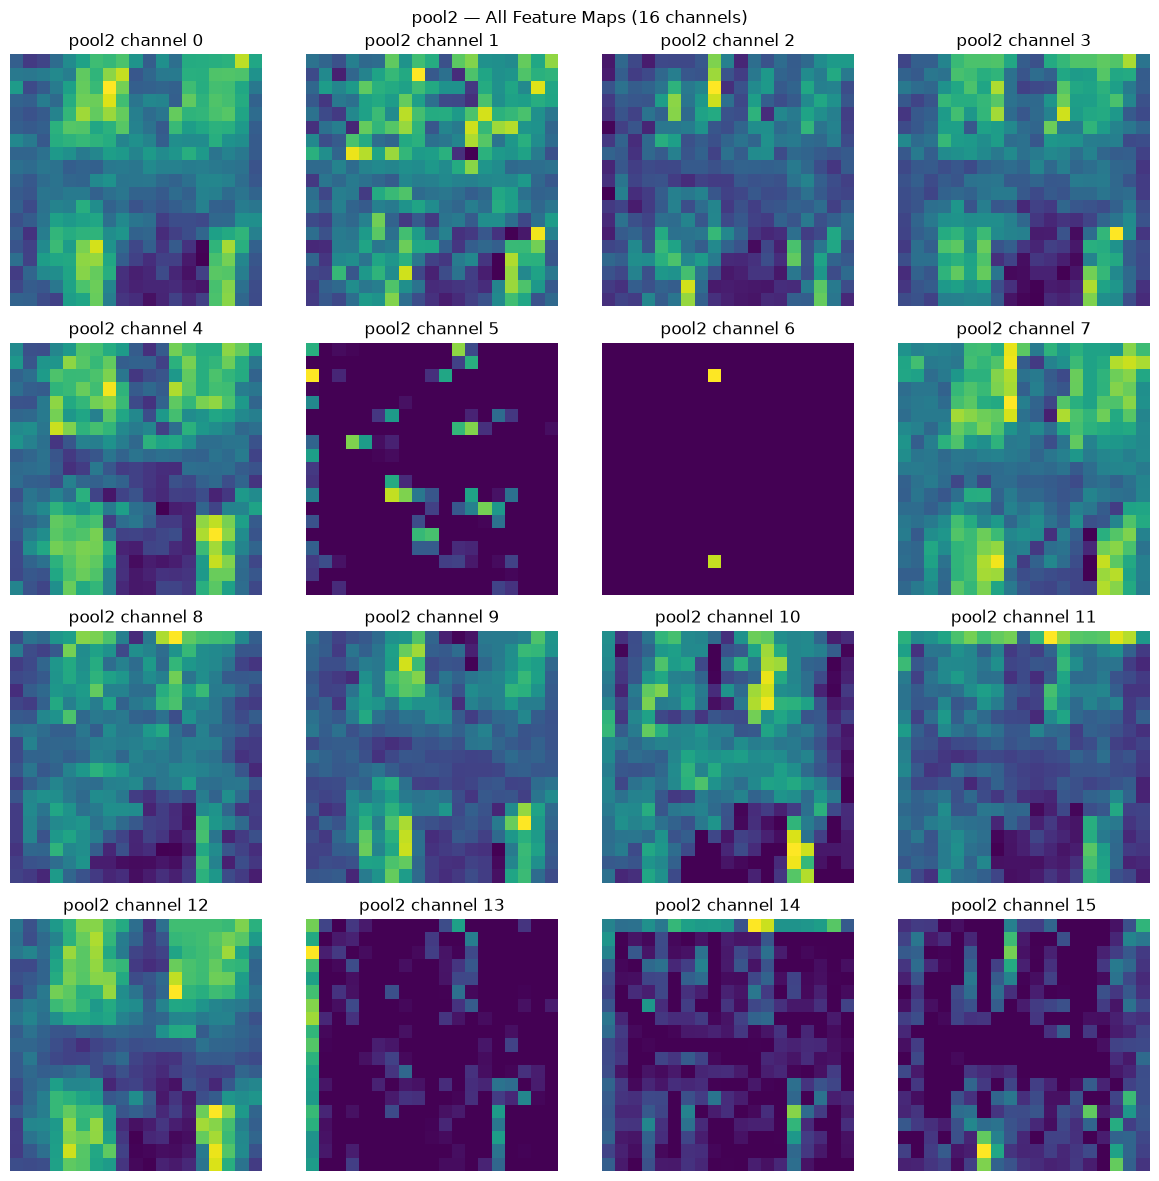

In [30]:
# Visualize what each conv layer learns.
# conv1 filters see RGB pixels; deeper layers see learned features.

sample_img = X_train[11:12]  # shape (1, 160, 160, 3)

# Visualize all conv1 learned RGB filters.
filters = conv1.W
n_filters = filters.shape[0]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    f = filters[i]
    f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f_norm, interpolation="nearest")
    ax.set_title(f"filter {i}")
    ax.axis("off")

fig.suptitle("conv1 Learned Filters (5x5x3)")
plt.tight_layout()
plt.show()


# Compute feature maps through the conv/pool stack.
A_conv1, _ = conv1.forward(sample_img)
A_pool1, _ = pool1.forward(A_conv1)
A_conv2, _ = conv2.forward(A_pool1)
A_pool2, _ = pool2.forward(A_conv2)


# Visualize all feature maps from each stage.
stages = [
    ("conv1", A_conv1),
    ("pool1", A_pool1),
    ("conv2", A_conv2),
    ("pool2", A_pool2),
]

for name, A in stages:
    n_channels = A.shape[-1]
    cols = 4
    rows = int(np.ceil(n_channels / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n_channels):
        axes[i].imshow(
            A[0, :, :, i],
            cmap="viridis",
            interpolation="nearest"
        )
        axes[i].set_title(f"{name} channel {i}")
        axes[i].axis("off")

    for i in range(n_channels, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"{name} — All Feature Maps ({n_channels} channels)"
    )
    plt.tight_layout()
    plt.show()